# NeuroFusionAI: Step 1 - Multimodal Data Preprocessing
This notebook walks through the data preparation and preprocessing pipeline of the three modalities:
1. **Hand-drawn Images** (resizing to 224x224 and splitting).
2. **Acoustic Voice Classification features** (feature standardization, duplicate removal, and stratified splitting).
3. **Tabular UPDRS Progression Telemonitoring features** (standardization and splitting).
We will import our modular preprocessing python package to execute the preprocessing.


In [1]:
import os
import sys
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import glob

# Resolve project root (walk up until we find the 'datasets' directory)
PROJECT_ROOT = os.path.abspath('.')
for p in [os.path.abspath(x) for x in sys.path if x]:
    if os.path.isdir(os.path.join(p, 'datasets')):
        PROJECT_ROOT = p
        break
    elif os.path.isdir(os.path.join(os.path.dirname(p), 'datasets')):
        PROJECT_ROOT = os.path.dirname(p)
        break
while not os.path.isdir(os.path.join(PROJECT_ROOT, 'datasets')) and PROJECT_ROOT != os.path.dirname(PROJECT_ROOT):
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)


Project root: d:\Parkison DATASET TRAINING


## 1. Run Preprocessing Pipelines
We execute the preprocessing functions that resize images, standardize tabular features, handle missing data, and create stratified splits.


In [2]:
from preprocessing.image_preprocessing import split_and_preprocess_images
from preprocessing.mri_preprocessing import split_and_preprocess_mri
from preprocessing.voice_preprocessing import preprocess_voice
from preprocessing.telemonitor_preprocessing import preprocess_telemonitor

print('Running Spiral Image Preprocessing...')
split_and_preprocess_images('datasets/raw_spiral', 'datasets/processed/images')

print('\nRunning MRI Preprocessing...')
split_and_preprocess_mri('datasets/mri', 'datasets/processed/mri')

print('\nRunning Oxford Voice Preprocessing...')
preprocess_voice('datasets/voice/oxford/parkinsons.data', 'datasets')

print('\nRunning Telemonitoring Preprocessing...')
preprocess_telemonitor('datasets/voice/telemonitoring/parkinsons_updrs.data', 'datasets')


2026-06-26 16:06:18,536 - image_preprocessing - INFO - Starting Image Preprocessing & Splitting...
2026-06-26 16:06:18,542 - image_preprocessing - INFO - Category 'normal': Found 610 images in datasets/raw_spiral\normal


Running Spiral Image Preprocessing...


2026-06-26 16:06:23,676 - image_preprocessing - INFO - Successfully processed and verified 610/610 images for category 'normal'
2026-06-26 16:06:31,048 - image_preprocessing - INFO - Copied 427/427 images to datasets\train\images\normal
2026-06-26 16:06:32,673 - image_preprocessing - INFO - Copied 91/91 images to datasets\validation\images\normal
2026-06-26 16:06:34,381 - image_preprocessing - INFO - Copied 92/92 images to datasets\test\images\normal
2026-06-26 16:06:34,386 - image_preprocessing - INFO - Category 'parkinson': Found 221 images in datasets/raw_spiral\parkinson
2026-06-26 16:06:36,185 - image_preprocessing - INFO - Successfully processed and verified 221/221 images for category 'parkinson'
2026-06-26 16:06:39,017 - image_preprocessing - INFO - Copied 154/154 images to datasets\train\images\parkinson
2026-06-26 16:06:39,661 - image_preprocessing - INFO - Copied 33/33 images to datasets\validation\images\parkinson
2026-06-26 16:06:40,294 - image_preprocessing - INFO - Copie


Running MRI Preprocessing...


2026-06-26 16:06:45,366 - mri_preprocessing - INFO - Successfully processed and verified 610/610 MRI images for category 'normal'
2026-06-26 16:06:52,850 - mri_preprocessing - INFO - Copied 427/427 MRI images to datasets\train\mri\normal
2026-06-26 16:06:54,401 - mri_preprocessing - INFO - Copied 91/91 MRI images to datasets\validation\mri\normal
2026-06-26 16:06:55,981 - mri_preprocessing - INFO - Copied 92/92 MRI images to datasets\test\mri\normal
2026-06-26 16:06:55,985 - mri_preprocessing - INFO - Category 'parkinson': Found 221 MRI images in datasets/mri\parkinson
2026-06-26 16:06:57,645 - mri_preprocessing - INFO - Successfully processed and verified 221/221 MRI images for category 'parkinson'
2026-06-26 16:07:00,294 - mri_preprocessing - INFO - Copied 154/154 MRI images to datasets\train\mri\parkinson
2026-06-26 16:07:00,892 - mri_preprocessing - INFO - Copied 33/33 MRI images to datasets\validation\mri\parkinson
2026-06-26 16:07:01,474 - mri_preprocessing - INFO - Copied 34/34 


Running Oxford Voice Preprocessing...
[Oxford Voice Dataset] No missing values found.

Running Telemonitoring Preprocessing...
[Telemonitoring Dataset] No missing values found.


2026-06-26 16:07:01,737 - telemonitor_preprocessing - INFO - Saved fully processed dataset with shape (5875, 21) to datasets\processed\telemonitoring\telemonitor_processed.csv
2026-06-26 16:07:01,738 - telemonitor_preprocessing - INFO - Splitting dataset into train, validation, and test sets...
2026-06-26 16:07:01,830 - telemonitor_preprocessing - INFO - Saved train split with shape (4112, 21) to datasets\train\telemonitoring\telemonitor_train.csv
2026-06-26 16:07:01,848 - telemonitor_preprocessing - INFO - Saved validation split with shape (881, 21) to datasets\validation\telemonitoring\telemonitor_validation.csv
2026-06-26 16:07:01,870 - telemonitor_preprocessing - INFO - Saved test split with shape (882, 21) to datasets\test\telemonitoring\telemonitor_test.csv
2026-06-26 16:07:01,871 - telemonitor_preprocessing - INFO - Telemonitoring dataset preprocessing and splitting completed successfully!


True

## 2. Visualize Preprocessed Drawings and Verify MRI
Let's display some control (normal) vs Parkinson drawings, and check the MRI count.


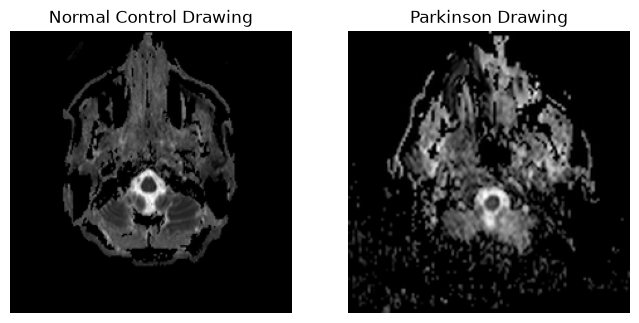

Found 427 normal MRIs and 154 Parkinson MRIs in train split.


In [3]:
normal_images = glob.glob('datasets/train/images/normal/*.png')
parkinson_images = glob.glob('datasets/train/images/parkinson/*.png')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
if normal_images:
    axes[0].imshow(Image.open(normal_images[0]))
    axes[0].set_title('Normal Control Drawing')
    axes[0].axis('off')
if parkinson_images:
    axes[1].imshow(Image.open(parkinson_images[0]))
    axes[1].set_title('Parkinson Drawing')
    axes[1].axis('off')
plt.show()

# Check MRI images if present
normal_mri = glob.glob('datasets/train/mri/normal/*.png') + glob.glob('datasets/train/mri/normal/*.jpg')
parkinson_mri = glob.glob('datasets/train/mri/parkinson/*.png') + glob.glob('datasets/train/mri/parkinson/*.jpg')
print(f'Found {len(normal_mri)} normal MRIs and {len(parkinson_mri)} Parkinson MRIs in train split.')


## 3. Verify Voice Acoustics Split Shape & Stats
Let's check the size and content of our voice splits.


In [4]:
train_voice = pd.read_csv('datasets/train/voice/oxford_train.csv')
print('Voice Train split shape:', train_voice.shape)
print('Distribution of Parkinson Status (1: Parkinson, 0: Healthy):')
print(train_voice['status'].value_counts(normalize=True))
train_voice.head(3)


Voice Train split shape: (136, 23)
Distribution of Parkinson Status (1: Parkinson, 0: Healthy):
status
1    0.757353
0    0.242647
Name: proportion, dtype: float64


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,-0.901677,-0.576823,-0.377834,-0.556376,-0.401899,-0.522409,-0.460177,-0.522488,-0.698573,-0.706109,...,-0.676827,-0.469980,0.806231,0,-1.071171,0.695422,-0.301784,0.033509,-1.332788,-0.483198
1,-0.009220,-0.343722,-1.164317,0.450720,0.173930,0.328898,0.382879,0.329943,0.446121,0.235361,...,0.098989,0.343868,-0.985405,1,1.558618,-0.253870,1.461230,0.433381,0.937320,1.767082
2,1.315052,0.254339,1.904999,-0.026979,-0.401899,0.126206,-0.020480,0.127251,-0.643279,-0.654662,...,-0.607046,-0.410448,0.118029,1,-1.547516,-0.102059,-0.723767,-0.506449,0.315623,-0.780546


## 4. Verify Telemonitoring UPDRS Split Shape & Stats
Let's inspect the tabular data and regression targets (`motor_UPDRS` and `total_UPDRS`) for severity tracking.


In [5]:
train_tele = pd.read_csv('datasets/train/telemonitoring/telemonitor_train.csv')
print('Telemonitoring Train split shape:', train_tele.shape)
print('Target statistics for severity assessment:')
print(train_tele[['motor_UPDRS', 'total_UPDRS']].describe())
train_tele.head(3)


Telemonitoring Train split shape: (4112, 21)
Target statistics for severity assessment:
       motor_UPDRS  total_UPDRS
count  4112.000000  4112.000000
mean     21.263284    29.004145
std       8.153072    10.740568
min       5.037700     7.000000
25%      14.890000    21.357500
50%      20.719000    27.490000
75%      27.555500    36.399000
max      39.511000    54.992000


,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,-1.111573,-0.682509,-0.469147,17.607,26.477,0.733717,0.813303,0.833287,0.515421,0.833271,...,-0.030230,-0.044251,-0.061466,-0.062592,-0.044247,-0.070263,-0.301230,0.183379,1.244787,0.954314
1,0.248852,-0.682509,-1.636340,12.362,18.362,0.399420,0.608191,0.580370,0.343895,0.579287,...,-0.099725,0.092498,-0.080671,-0.238729,0.092250,-0.174976,-0.197285,-0.757824,1.815341,0.416882
2,-0.884836,-0.682509,0.775177,28.503,37.485,0.074014,-0.071348,0.093744,0.027645,0.093731,...,-0.508005,-0.505871,-0.441361,-0.569986,-0.505614,0.050885,0.237373,0.089892,-0.844472,1.042956
